# Exploratory Analysis

This notebook provides an exploratory overview of histological image data derived from The Cancer Genome Atlas (TCGA), focusing on samples stratified by their molecular and mutational profiles. The dataset includes three biologically distinct subgroups: 
- **MSS/TMB-H (Tumor Mutational Burden – High)**: Tumors with high mutational burden
- **MSS/TMB-L (Microsatellite Stable or Tumor Mutational Burden – Low)**: Stable tumors with low mutational burden
- **MSI-H (Microsatellite Instability – High)**: Tumors with high microsatellite instability

The goal of this analysis is to gain an initial understanding of the dataset composition, structure, and potential relationships between these subgroups. Before performing any predictive modeling or feature extraction, it is essential to examine how these groups differ in terms of image-derived characteristics and metadata distributions.


## Objectives

The primary goal is to comprehensively understand the dataset composition, structure, and biological patterns before predictive modeling. This analysis will:

1. Establish data quality and identify anomalies
2. Characterize distributions at both tile and case levels
3. Identify statistical differences between molecular subgroups


## Analysis Structure
[1. Data Loading and Basic Structure](##1.-Data-Loading-and-Basic-Structure)

[2. Data Quality Assessment](##2.-Data-Quality-Assessment)

[3. Case-Level Analysis](##3.-Case-Level-Analysis)

[4. Tile-Level Descriptive Statistics](##4.-Tile-Level-Descriptive-Statistics)

[5. Correlation and Feature Relationships](##5.-Correlation-and-Feature-Relationships)

[6. Group Comparisons](##6.-Group-Comparisons)

## The Five Cell Types:
| Cell Type | Description |
| :--- | :--- |
| **Neoplastic** | The cancer cells themselves. Show abnormal morphology and drive tumor growth. |
| **Inflammatory** | Immune cells (lymphocytes, macrophages, etc.). These are tumor-infiltrating immune cells and are important for immunotherapy response. |
| **Connective** | Stromal cells (fibroblasts, endothelial cells) that provide the support structure. |
| **Necrosis** | Regions of cell death, which are common in aggressive tumors. |
| **Non-neoplastic** | Normal cells, such as adjacent normal epithelium or benign tissue at the margins. |
| **Nolabel** | Cells that could not be classified by the analysis. |

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Plotting style
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10

# Define color palette for consistency
GROUP_COLORS = {
    'MSS/TMB-H': '#E74C3C',
    'MSS/TMB-L': '#3498DB',
    'MSI-H': '#2ECC71'
}

## 1. Data Loading and Basic Structure

Loading the three separate CSV files representing the three molecular subgroups and combine them into a single dataset.

In [2]:
tmb = pd.read_csv('/cfs/earth/scratch/visciric/tumor-segmentation-ucec-stad/data/processed_csv/mss_tmb-h.csv')
mss = pd.read_csv('/cfs/earth/scratch/visciric/tumor-segmentation-ucec-stad/data/processed_csv/mss_tmb-l.csv')
msi = pd.read_csv('/cfs/earth/scratch/visciric/tumor-segmentation-ucec-stad/data/processed_csv/msi-h.csv')

In [14]:
# Add group labels
tmb['group'] = 'MSS/TMB-H'
mss['group'] = 'MSS/TMB-L'
msi['group'] = 'MSI-H'

# Combine datasets
df_combined = pd.concat([tmb, mss, msi], ignore_index=True)

In [4]:
df_combined.to_csv('/cfs/earth/scratch/visciric/tumor-segmentation-ucec-stad/data/processed_csv/combined_wsi_data.csv', index= False)

In [15]:
# Dataset overview
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nDataset Sizes:")
print(f"  MSS/TMB-H:      {len(tmb):>10,} tiles  ({len(tmb)/len(df_combined)*100:5.2f}%)")
print(f"  MSS/TMB-L:  {len(mss):>10,} tiles  ({len(mss)/len(df_combined)*100:5.2f}%)")
print(f"  MSI-H:      {len(msi):>10,} tiles  ({len(msi)/len(df_combined)*100:5.2f}%)")
print(f"  {'─'*50}")
print(f"  Total:      {len(df_combined):>10,} tiles")

print(f"\nCases per Group:")
for group in ['MSS/TMB-H', 'MSS/TMB-L', 'MSI-H']:
    n_cases = df_combined[df_combined['group'] == group]['case_id'].nunique()
    print(f"  {group:12s}  {n_cases:>4} cases")
print(f"  {'─'*50}")
print(f"  Total:           {df_combined['case_id'].nunique():>4} cases")

print(f"\nData Structure:")
print(f"  Shape:      {df_combined.shape[0]:,} rows × {df_combined.shape[1]} columns")
print(f"  Memory:     {df_combined.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\nMissing Values Check:")
missing = df_combined.isnull().sum()
if missing.sum() == 0:
    print("  No missing values detected")
else:
    print("\nColumns with missing values:")
    for col, count in missing[missing > 0].items():
        print(f"    {col}: {count:,} ({count/len(df_combined)*100:.2f}%)")

DATASET OVERVIEW

Dataset Sizes:
  MSS/TMB-H:         160,305 tiles  ( 5.66%)
  MSS/TMB-L:   1,802,641 tiles  (63.61%)
  MSI-H:         870,842 tiles  (30.73%)
  ──────────────────────────────────────────────────
  Total:       2,833,788 tiles

Cases per Group:
  MSS/TMB-H       31 cases
  MSS/TMB-L      320 cases
  MSI-H          163 cases
  ──────────────────────────────────────────────────
  Total:            514 cases

Data Structure:
  Shape:      2,833,788 rows × 35 columns
  Memory:     1361.1 MB

Missing Values Check:
  No missing values detected


In [16]:
# Display column information
print("\nColumn Information:")
print(df_combined.dtypes.to_string())


Column Information:
case_id                       object
label                         object
tile_x                         int64
tile_y                         int64
tile_id                       object
x_start                        int64
y_start                        int64
x_end                          int64
y_end                          int64
width                          int64
height                         int64
area                           int64
coverage_pct                 float64
is_partial                      bool
is_edge_right                   bool
is_edge_bottom                  bool
nolabel                        int64
neoplastic                     int64
inflammatory                   int64
connective                     int64
necrosis                       int64
non_neoplastic                 int64
total_nuclei                   int64
neoplastic_pct               float64
inflammatory_pct             float64
connective_pct               float64
necrosis_pct     


Group Statistics Summary:

           n_tiles  n_cases  tiles_per_case  pct_tiles  pct_cases
group                                                            
MSI-H       870842      163        5342.600     30.700     31.700
MSS/TMB-H   160305       31        5171.100      5.700      6.000
MSS/TMB-L  1802641      320        5633.300     63.600     62.300


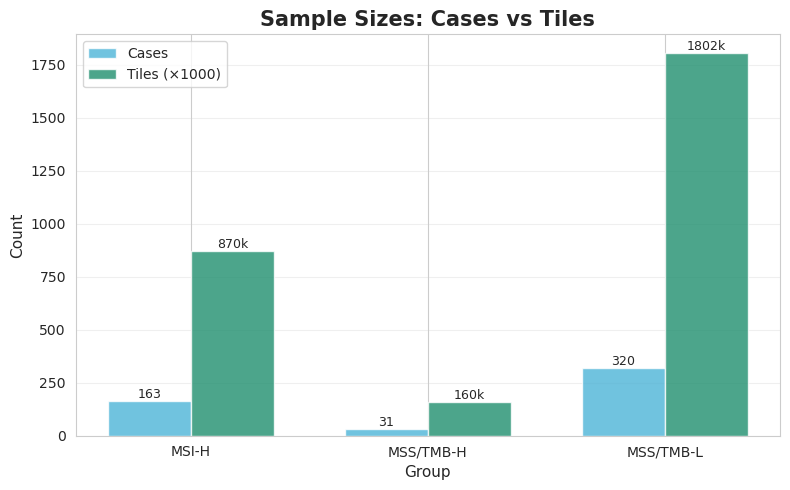

In [29]:
# Calculate group statistics
group_stats = df_combined.groupby('group').agg({
    'tile_id': 'count',
    'case_id': 'nunique'
}).rename(columns={'tile_id': 'n_tiles', 'case_id': 'n_cases'})

group_stats['tiles_per_case'] = (group_stats['n_tiles'] / group_stats['n_cases']).round(1)
group_stats['pct_tiles'] = (group_stats['n_tiles'] / group_stats['n_tiles'].sum() * 100).round(1)
group_stats['pct_cases'] = (group_stats['n_cases'] / group_stats['n_cases'].sum() * 100).round(1)

# Print summary table
print("\nGroup Statistics Summary:\n")
print(group_stats.to_string())

# Visualize data structure
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Sample size comparison
x = np.arange(len(group_stats))
width = 0.35

bars1 = ax.bar(x - width/2, group_stats['n_cases'], width,
               label='Cases', alpha=0.8, color='#4cb4d7')
bars2 = ax.bar(x + width/2, group_stats['n_tiles']/1000, width,
               label='Tiles (×1000)', alpha=0.8, color='#1f8f6e')

ax.set_xlabel('Group', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Sample Sizes: Cases vs Tiles', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(group_stats.index, rotation=0)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}k',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('images/00_data_structure.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Data Quality Assessment
Comprehensive validation to identify anomalies, outliers, and data integrity issues.

**Validates:**
1. **Percentage completeness** - All cell type percentages sum to 100%
2. **Normalization accuracy** - Partial tiles correctly scaled to full-tile equivalents
3. **Value ranges** - No negative counts or percentages exceeding 100%
4. **Data distribution** - Statistical summary of cell counts (min, max, median, mean)
5. **Outlier detection** - Identifies tiles with extreme cell densities using IQR method

**Purpose:** Catches calculation errors, impossible values, and flags unusual tiles before downstream analysis.

In [8]:
print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

# 1. Percentage validation 
print("\n1. Percentage Column Validation:")
pct_cols = ['neoplastic_pct', 'inflammatory_pct', 'connective_pct', 
            'necrosis_pct', 'non_neoplastic_pct']
nolabel_pct = (df_combined['nolabel'] / df_combined['total_nuclei']) * 100
all_pct_sum = df_combined[pct_cols].sum(axis=1) + nolabel_pct
tolerance = 0.1
valid_sum = ((all_pct_sum >= 100 - tolerance) & (all_pct_sum <= 100 + tolerance)).sum()
if valid_sum == len(df_combined):
    print(f" All percentage columns sum to 100% (including nolabel)")
    print(f"    Mean sum: {all_pct_sum.mean():.2f}%")
else:
    print(f" {len(df_combined) - valid_sum:,} tiles outside tolerance")

# 2. Normalization Check (only validates partial tiles)
print("\n2. Normalization Validation:")
TILE_SIZE = 896
tile_area_full = TILE_SIZE * TILE_SIZE  

# For full tiles, normalized should equal actual count
full_tiles = df_combined[~df_combined['is_partial']]
full_tiles_match = (full_tiles['total_normalized'] == full_tiles['total_nuclei']).all()

# For partial tiles, normalized should be scaled up
partial_tiles = df_combined[df_combined['is_partial']]
if len(partial_tiles) > 0:
    calc_norm = partial_tiles['total_nuclei'] * (tile_area_full / partial_tiles['area'])
    partial_match = np.allclose(partial_tiles['total_normalized'], calc_norm, rtol=1e-5)
else:
    partial_match = True

if full_tiles_match and partial_match:
    print(f" Normalization correct for all tiles")
    print(f"    Full tiles: {len(full_tiles):,} (normalized = actual)")
    print(f"    Partial tiles: {len(partial_tiles):,} (normalized = scaled)")
else:
    if not full_tiles_match:
        print(f" Full tiles: normalized values don't match actual counts")
    if not partial_match:
        print(f" Partial tiles: normalization formula mismatch")

# 3. Value Range Validation
print("\n3. Value Range Validation:")
# Check percentages
invalid_pct = 0
for col in pct_cols:
    invalid = ((df_combined[col] < 0) | (df_combined[col] > 100)).sum()
    invalid_pct += invalid

# Check normalized values (should be >= actual counts)
norm_cols = ['neoplastic_normalized', 'inflammatory_normalized', 'connective_normalized',
             'necrosis_normalized', 'non_neoplastic_normalized', 'total_normalized']
count_cols = ['neoplastic', 'inflammatory', 'connective',
              'necrosis', 'non_neoplastic', 'total_nuclei']

invalid_norm = 0
for norm_col, count_col in zip(norm_cols, count_cols):
    # Normalized values should be >= actual counts (or equal for full tiles)
    invalid = (df_combined[norm_col] < df_combined[count_col] - 0.01).sum()  # small tolerance for float
    invalid_norm += invalid

if invalid_pct == 0:
    print(f" All percentages in valid range [0, 100]")
else:
    print(f" {invalid_pct:,} invalid percentage values")

if invalid_norm == 0:
    print(f" All normalized values >= actual counts (as expected)")
else:
    print(f" {invalid_norm:,} normalized values less than actual counts")

# 4. Data Range Summary
print("\n4. Data Range Summary:")
print(f"\n  Total Nuclei (actual counts):")
print(f"    Range: [{df_combined['total_nuclei'].min():.0f}, {df_combined['total_nuclei'].max():.0f}]")
print(f"    Median: {df_combined['total_nuclei'].median():.0f}")
print(f"    Mean: {df_combined['total_nuclei'].mean():.1f}")

print(f"\n  Total Nuclei (normalized to full tile):")
print(f"    Range: [{df_combined['total_normalized'].min():.1f}, {df_combined['total_normalized'].max():.1f}]")
print(f"    Median: {df_combined['total_normalized'].median():.1f}")
print(f"    Mean: {df_combined['total_normalized'].mean():.1f}")

print(f"\n  Neoplastic Cells:")
print(f"    Actual range: [{df_combined['neoplastic'].min():.0f}, {df_combined['neoplastic'].max():.0f}]")
print(f"    Normalized range: [{df_combined['neoplastic_normalized'].min():.1f}, {df_combined['neoplastic_normalized'].max():.1f}]")
print(f"    Percentage median: {df_combined['neoplastic_pct'].median():.1f}%")

print(f"\n  Inflammatory Cells:")
print(f"    Actual range: [{df_combined['inflammatory'].min():.0f}, {df_combined['inflammatory'].max():.0f}]")
print(f"    Normalized range: [{df_combined['inflammatory_normalized'].min():.1f}, {df_combined['inflammatory_normalized'].max():.1f}]")
print(f"    Percentage median: {df_combined['inflammatory_pct'].median():.1f}%")

# 5. Outlier Analysis
print("\n5. Outlier Analysis:")
Q1 = df_combined['total_normalized'].quantile(0.25)
Q3 = df_combined['total_normalized'].quantile(0.75)
IQR = Q3 - Q1
extreme_outliers = ((df_combined['total_normalized'] < Q1 - 3*IQR) | 
                    (df_combined['total_normalized'] > Q3 + 3*IQR)).sum()
print(f"  Extreme outliers in normalized cell count (>3×IQR): {extreme_outliers:,} ({extreme_outliers/len(df_combined)*100:.2f}%)")
if extreme_outliers > 0:
    print(f"  These represent tiles with unusually high/low cell density")
else:
    print(f"  No extreme outliers detected")

print(f"\n  IQR Details (normalized counts):")
print(f"    Q1: {Q1:.1f} cells")
print(f"    Q3: {Q3:.1f} cells")
print(f"    IQR: {IQR:.1f} cells")


DATA QUALITY ASSESSMENT

1. Percentage Column Validation:
 All percentage columns sum to 100% (including nolabel)
    Mean sum: 100.00%

2. Normalization Validation:
 Normalization correct for all tiles
    Full tiles: 2,830,467 (normalized = actual)
    Partial tiles: 3,321 (normalized = scaled)

3. Value Range Validation:
 All percentages in valid range [0, 100]
 All normalized values >= actual counts (as expected)

4. Data Range Summary:

  Total Nuclei (actual counts):
    Range: [1, 4683]
    Median: 307
    Mean: 329.4

  Total Nuclei (normalized to full tile):
    Range: [1.0, 1239642.4]
    Median: 307.0
    Mean: 336.2

  Neoplastic Cells:
    Actual range: [0, 1742]
    Normalized range: [0.0, 1182973.0]
    Percentage median: 13.1%

  Inflammatory Cells:
    Actual range: [0, 3561]
    Normalized range: [0.0, 127232.0]
    Percentage median: 5.5%

5. Outlier Analysis:
  Extreme outliers in normalized cell count (>3×IQR): 31,114 (1.10%)
  These represent tiles with unusually

## 3. Case-Level Analysis

Aggregating tile-level data to understand patient-level patterns and variability. This is crucial for:
- Understanding data imbalance at the case level
- Identifying cases with unusual characteristics
- Planning train/test splits that respect case boundaries

In [18]:
print("="*60)
print("CASE-LEVEL ANALYSIS")
print("="*60)

# Aggregate statistics per case
case_stats = df_combined.groupby(['case_id', 'group']).agg({
    'tile_id': 'count',
    'total_nuclei': ['sum', 'mean', 'std'],
    'neoplastic_pct': ['mean', 'std'],
    'inflammatory_pct': ['mean', 'std'],
    'connective_pct': ['mean', 'std'],
    'necrosis_pct': ['mean', 'std'],
    'non_neoplastic_pct': ['mean', 'std'],
    'total_normalized': ['mean', 'std']
}).reset_index()

# Flatten column names
case_stats.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in case_stats.columns.values]
case_stats.rename(columns={'tile_id_count': 'n_tiles'}, inplace=True)

print("\n Tiles per Case Distribution:")
print("\nOverall Statistics:")
print(f"  Mean:     {case_stats['n_tiles'].mean():>8.1f} tiles/case")
print(f"  Median:   {case_stats['n_tiles'].median():>8.0f} tiles/case")
print(f"  Std Dev:  {case_stats['n_tiles'].std():>8.1f}")
print(f"  Min:      {case_stats['n_tiles'].min():>8.0f} tiles/case")
print(f"  Max:      {case_stats['n_tiles'].max():>8.0f} tiles/case")

print("\nBy Group:")
for group in ['MSS/TMB-H', 'MSS/TMB-L', 'MSI-H']:
    group_cases = case_stats[case_stats['group'] == group]['n_tiles']
    print(f"\n  {group}:")
    print(f"    Mean:   {group_cases.mean():>8.1f} tiles/case")
    print(f"    Median: {group_cases.median():>8.0f} tiles/case")
    print(f"    Range:  [{group_cases.min():.0f}, {group_cases.max():.0f}]")

# Identify cases with extreme tile counts
print("\n Cases with Extreme Tile Counts:")
Q1 = case_stats['n_tiles'].quantile(0.25)
Q3 = case_stats['n_tiles'].quantile(0.75)
IQR = Q3 - Q1
extreme_low = case_stats[case_stats['n_tiles'] < Q1 - 1.5*IQR]
extreme_high = case_stats[case_stats['n_tiles'] > Q3 + 1.5*IQR]

print(f"  Very few tiles (< {Q1 - 1.5*IQR:.0f}):  {len(extreme_low)} cases")
print(f"  Very many tiles (> {Q3 + 1.5*IQR:.0f}): {len(extreme_high)} cases")

if len(extreme_low) > 0:
    print(f"\n  Cases with fewest tiles:")
    for _, row in extreme_low.nsmallest(3, 'n_tiles').iterrows():
        print(f"    {row['case_id']}: {row['n_tiles']:.0f} tiles ({row['group']})")

CASE-LEVEL ANALYSIS

 Tiles per Case Distribution:

Overall Statistics:
  Mean:       5513.2 tiles/case
  Median:       5676 tiles/case
  Std Dev:    2777.5
  Min:           188 tiles/case
  Max:         14806 tiles/case

By Group:

  MSS/TMB-H:
    Mean:     5171.1 tiles/case
    Median:     5825 tiles/case
    Range:  [784, 9324]

  MSS/TMB-L:
    Mean:     5633.3 tiles/case
    Median:     5986 tiles/case
    Range:  [188, 12780]

  MSI-H:
    Mean:     5342.6 tiles/case
    Median:     5403 tiles/case
    Range:  [266, 14806]

 Cases with Extreme Tile Counts:
  Very few tiles (< -2133):  0 cases
  Very many tiles (> 13028): 1 cases


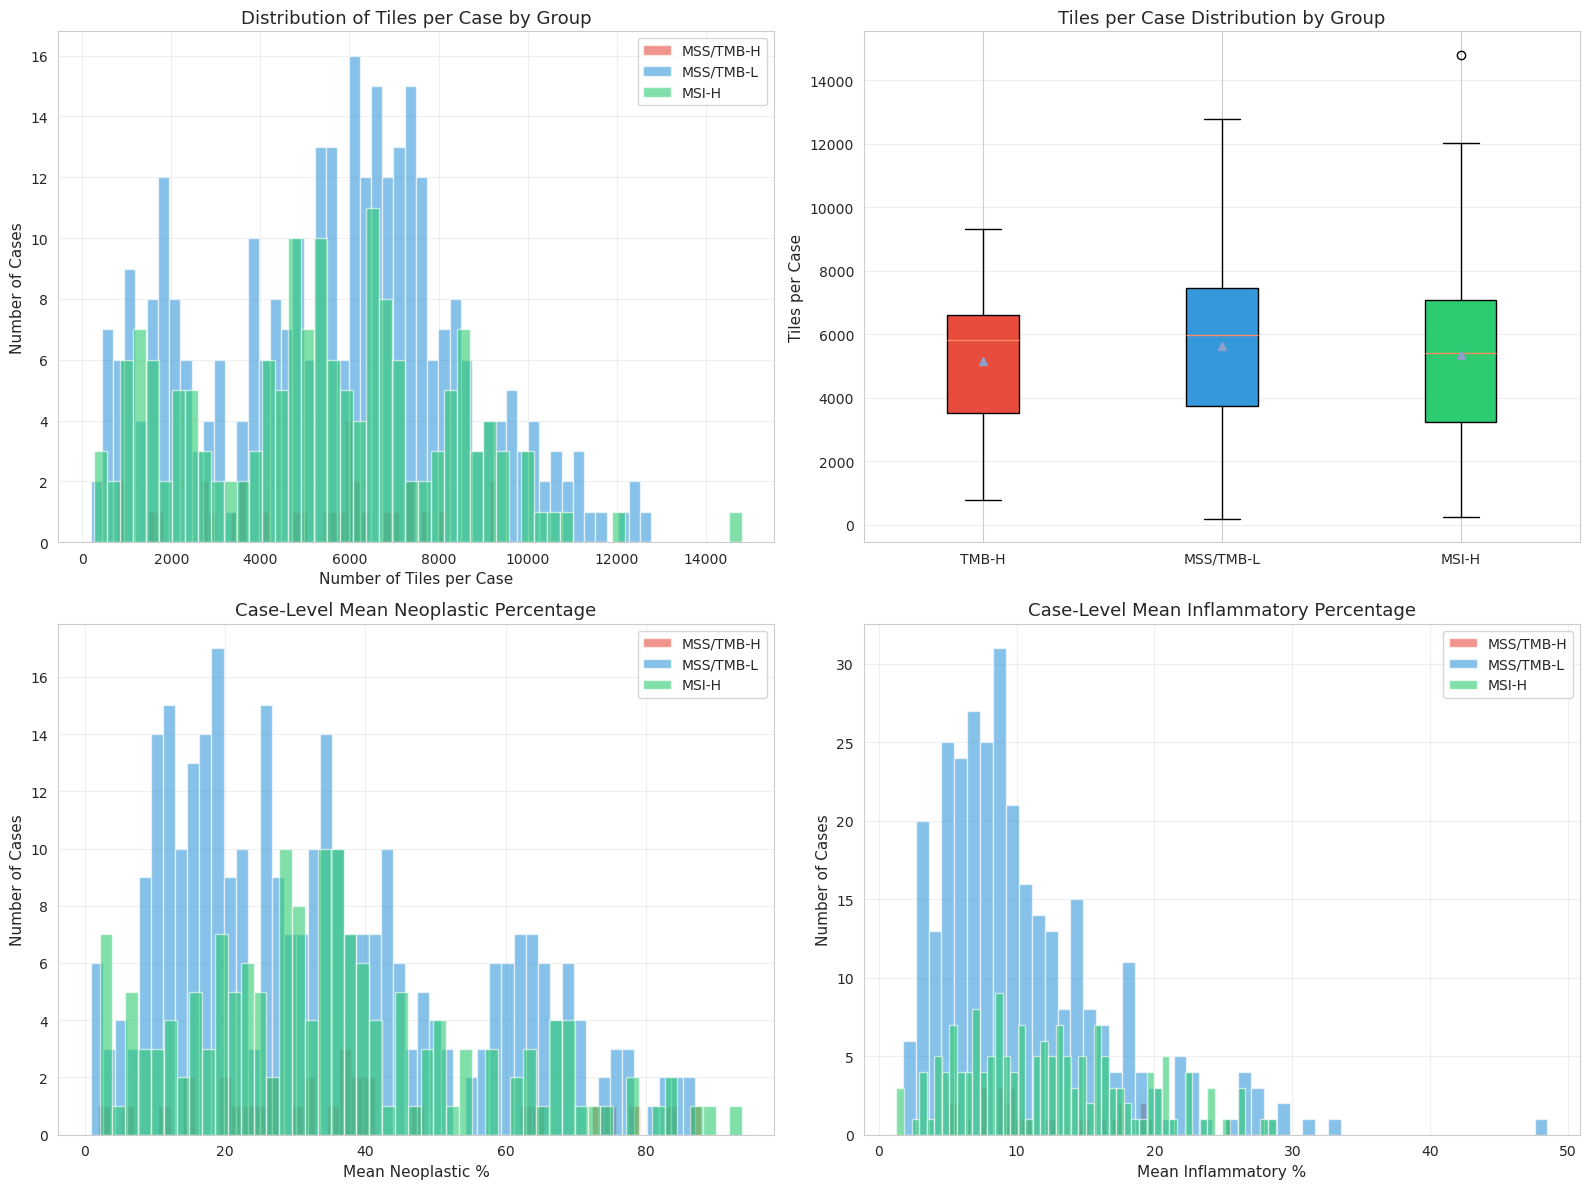

In [28]:
# Visualize case-level distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Tiles per case distribution
for group, color in GROUP_COLORS.items():
    data = case_stats[case_stats['group'] == group]['n_tiles']
    axes[0, 0].hist(data, bins=50, alpha=0.6, label=group, color=color)
axes[0, 0].set_xlabel('Number of Tiles per Case')
axes[0, 0].set_ylabel('Number of Cases')
axes[0, 0].set_title('Distribution of Tiles per Case by Group')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot of tiles per case
case_stats_plot = []
for group in ['MSS/TMB-H', 'MSS/TMB-L', 'MSI-H']:
    case_stats_plot.append(case_stats[case_stats['group'] == group]['n_tiles'].values)
bp = axes[0, 1].boxplot(case_stats_plot, labels=['TMB-H', 'MSS/TMB-L', 'MSI-H'],
                         patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], GROUP_COLORS.values()):
    patch.set_facecolor(color)
axes[0, 1].set_ylabel('Tiles per Case')
axes[0, 1].set_title('Tiles per Case Distribution by Group')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Mean neoplastic percentage per case
for group, color in GROUP_COLORS.items():
    data = case_stats[case_stats['group'] == group]['neoplastic_pct_mean']
    axes[1, 0].hist(data, bins=50, alpha=0.6, label=group, color=color)
axes[1, 0].set_xlabel('Mean Neoplastic %')
axes[1, 0].set_ylabel('Number of Cases')
axes[1, 0].set_title('Case-Level Mean Neoplastic Percentage')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Mean inflammatory percentage per case
for group, color in GROUP_COLORS.items():
    data = case_stats[case_stats['group'] == group]['inflammatory_pct_mean']
    axes[1, 1].hist(data, bins=50, alpha=0.6, label=group, color=color)
axes[1, 1].set_xlabel('Mean Inflammatory %')
axes[1, 1].set_ylabel('Number of Cases')
axes[1, 1].set_title('Case-Level Mean Inflammatory Percentage')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/01_case_level_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

The number of tiles processed per case varies extensively across all groups, ranging from fewer than 1,000 to over 14,000, with the TMB-H cohort displaying a slightly lower median tile count and a narrower interquartile range compared to the MSS/TMB-L and MSI-H cohorts. While the case-level mean neoplastic percentage shows a wide, dispersed distribution spanning approximately 5% to 90%, the mean inflammatory percentage is distinctly right-skewed, with the highest density of cases falling between 5% and 15% across all three subgroups.

## 4. Tile-Level Descriptive Statistics

Examining the distribution of key cellular and morphological features at the tile level.

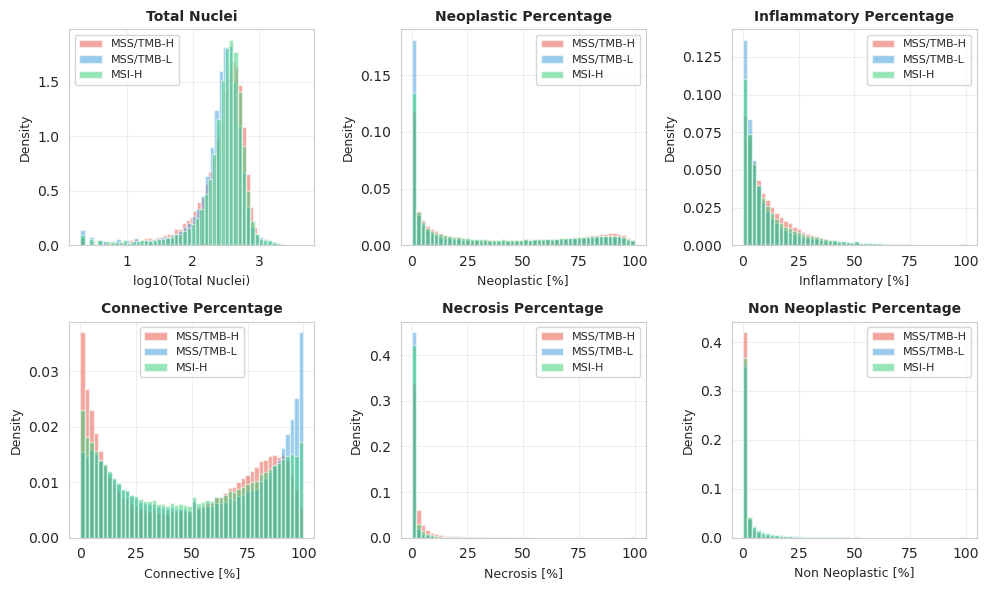

In [27]:
# Visualize distributions of key metrics
fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()

metrics_to_plot = ['total_nuclei', 'neoplastic_pct', 'inflammatory_pct',
                   'connective_pct', 'necrosis_pct', 'non_neoplastic_pct']

for idx, metric in enumerate(metrics_to_plot):
    for group, color in GROUP_COLORS.items():
        data = df_combined[df_combined['group'] == group][metric]
        
        if metric == 'total_nuclei':
            data_plot = np.log10(data + 1) 
            xlabel = 'log10(Total Nuclei)'
        elif '_pct' in metric:
            data_plot = data
            xlabel = metric.replace('_pct', '').replace('_', ' ').title() + ' [%]'
        
        else:
            data_plot = data
            xlabel = metric.replace('_', ' ').title()
        
        axes[idx].hist(data_plot, bins=50, alpha=0.5, label=group, color=color, density=True)
    
    if '_pct' in metric:
        title = metric.replace('_pct', '').replace('_', ' ').title() + ' Percentage'
    else:
        title = metric.replace('_', ' ').title()
    
    axes[idx].set_xlabel(xlabel, fontsize=9)
    axes[idx].set_ylabel('Density', fontsize=9)
    axes[idx].set_title(title, fontsize=10, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/02_tile_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

The distributions for Neoplastic, Inflammatory, Necrosis, and Non-Neoplastic percentages are strongly right-skewed across all three cohorts, indicating that the majority of samples contain low proportions of these specific cell types. In contrast, the Connective Percentage distribution is bimodal, particularly in the **MSS/TMB-L** group, which exhibits a prominent density peak near 100%, suggesting a subset of samples is dominated almost entirely by connective tissue.

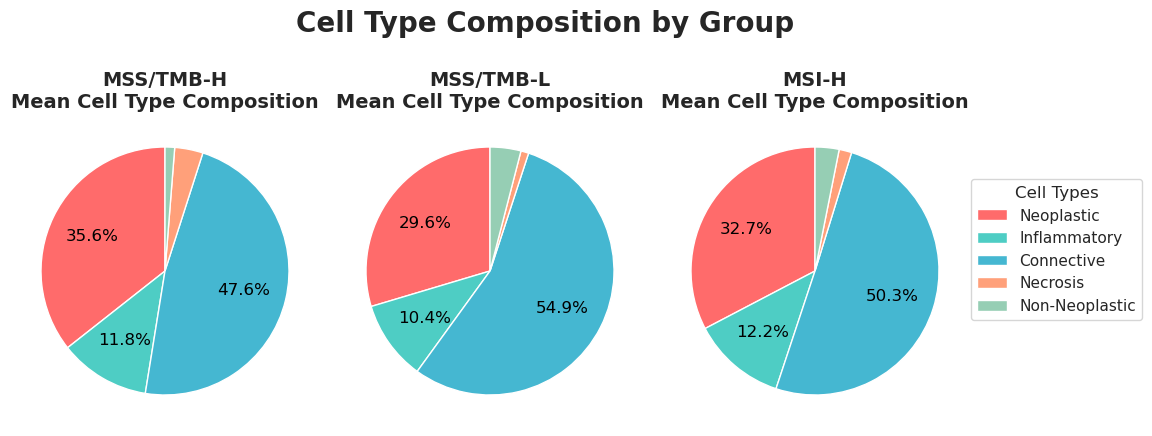

In [26]:
# Cell type composition
fig, axes = plt.subplots(1, 3, figsize=(11, 5))   

groups = ['MSS/TMB-H', 'MSS/TMB-L', 'MSI-H']
labels = ['Neoplastic', 'Inflammatory', 'Connective', 'Necrosis', 'Non-Neoplastic']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#96CEB4']

def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 5 else ''

wedges_for_legend = None  

for ax, group in zip(axes, groups):
    data = df_combined[df_combined['group'] == group]
    
    means = [
        data['neoplastic_pct'].mean(),
        data['inflammatory_pct'].mean(),
        data['connective_pct'].mean(),
        data['necrosis_pct'].mean(),
        data['non_neoplastic_pct'].mean()
    ]
    
    wedges, texts, autotexts = ax.pie(
        means, labels=None, colors=colors,
        autopct=autopct_format, startangle=90,
        pctdistance=0.65
    )
    
    if wedges_for_legend is None:
        wedges_for_legend = wedges
    
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(12)
    
    ax.set_title(f'{group}\nMean Cell Type Composition', 
                 fontsize=14, fontweight='bold')

# Shared legend (only once!)
fig.legend(
    wedges_for_legend, labels,
    loc='center right',
    bbox_to_anchor=(1.05, 0.5),
    fontsize=11,
    title='Cell Types',
    title_fontsize=12
)

plt.suptitle('Cell Type Composition by Group', 
             fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for legend
plt.savefig('images/03_composition_pie.png', dpi=300, bbox_inches='tight')
plt.show()


Across all three groups (MSS/TMB-H, MSS/TMB-L, and MSI-H), connective tissue is the predominant cell type, ranging from 47.6% to 54.9% of the mean composition. Neoplastic cells constitute the second largest proportion in every category, with the highest percentage observed in the MSS/TMB-H group (35.6%) and the lowest in the MSS/TMB-L group (29.6%).

## 5. Correlation and Feature Relationships

Analyzing correlations between features to understand multicollinearity and feature redundancy.

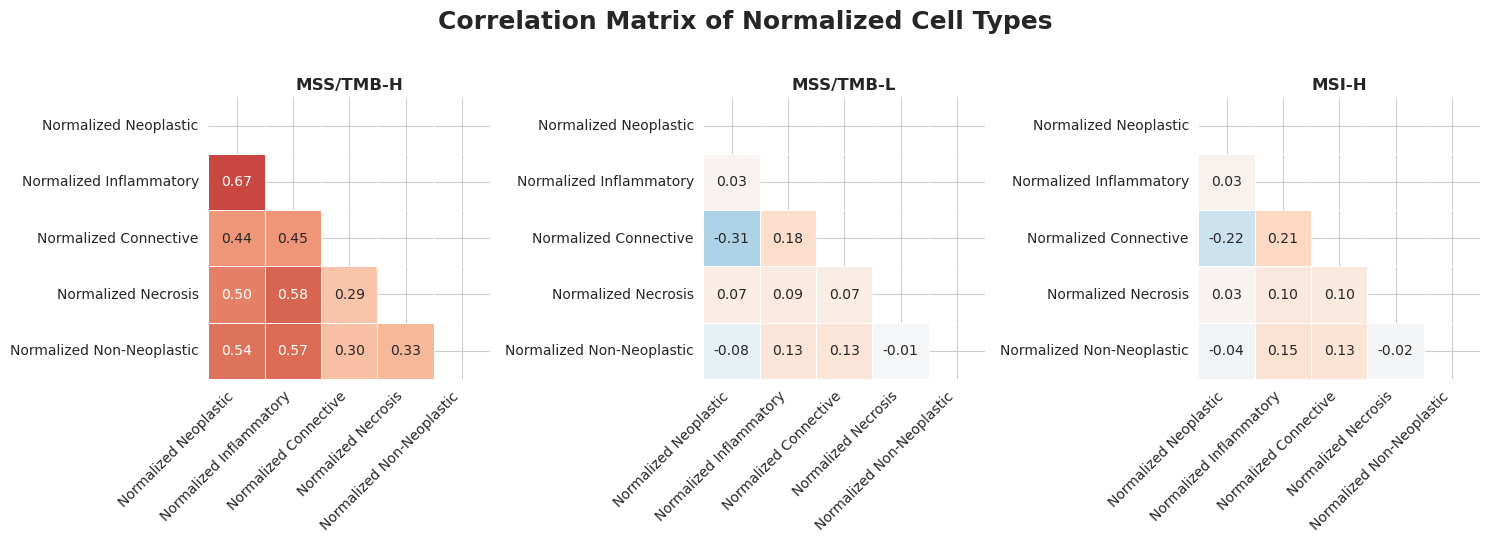

In [25]:

normalized_cols = ['neoplastic_normalized', 'inflammatory_normalized', 
                   'connective_normalized', 'necrosis_normalized', 
                   'non_neoplastic_normalized']

# Create a mapping for proper column names
col_name_mapping = {
    'neoplastic_normalized': 'Normalized Neoplastic',
    'inflammatory_normalized': 'Normalized Inflammatory',
    'connective_normalized': 'Normalized Connective',
    'necrosis_normalized': 'Normalized Necrosis',
    'non_neoplastic_normalized': 'Normalized Non-Neoplastic'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (ax, group) in enumerate(zip(axes, ['MSS/TMB-H', 'MSS/TMB-L', 'MSI-H'])):
    group_data = df_combined[df_combined['group'] == group][normalized_cols]
    
    group_data_renamed = group_data.rename(columns=col_name_mapping)
    corr = group_data_renamed.corr()
   
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, ax=ax, cbar=False,
                vmin=-1, vmax=1, linewidths=0.5)
    
    ax.set_title(f'{group}', fontweight='bold', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.suptitle('Correlation Matrix of Normalized Cell Types', fontweight='bold', fontsize=18, y= 1.05)
plt.tight_layout()
plt.savefig('images/04_correlations_normalized.png', dpi=300, bbox_inches='tight')
plt.show()


The **MSS/TMB-H** group exhibits strong positive correlations between most normalized cell types, particularly between Neoplastic and Inflammatory cells (0.67), whereas the **MSS/TMB-L** and **MSI-H** groups show predominantly weak or negligible correlations across cell types. While Normalized Neoplastic cells in the **MSS/TMB-H** subgroup show moderate-to-strong positive associations with all other cell types (range: 0.44–0.67), the same cell type in the **MSS/TMB-L** and **MSI-H** subgroups displays weak negative correlations with Normalized Connective cells (-0.31 and -0.22, respectively).

# Discussion
In the exploratory analysis, we obtained a first glimpse into the data structure and quality. We observed that the MSS/TMB-H cohort represents the smallest proportion of the dataset with only 31 samples, compared to the largest group, MSS/TMB-L, which contains 320 samples. This class imbalance will have significant implications for downstream modeling and performance evaluation. Furthermore, while we observed that the cell type composition is similar across all groups, dominated by connective tissue ($~47-55\%$) and neoplastic cells ($~30-35\%$),the inter-cellular relationships vary drastically. Unlike the larger cohorts, the MSS/TMB-H group exhibits strong positive correlations between neoplastic and inflammatory cells, suggesting a distinct, more coupled immune-tumor microenvironment in these high-mutational-burden cases.